In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\lenovo\Downloads\dataanalytics.csv")
df.head(4)

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19


In [3]:
df.shape


(1200, 14)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


In [5]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [6]:
df['TotalPrice'].mean()

np.float64(1053.9683)

In [7]:
df['TotalPrice'].median()

823.615

In [8]:
df['Product'].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

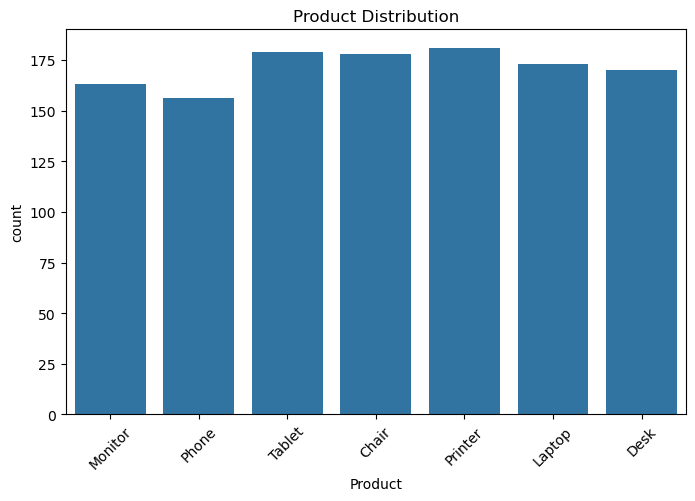

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x='Product', data=df)
plt.title("Product Distribution")
plt.xticks(rotation=45)
plt.show()

In [10]:
df['PaymentMethod'].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

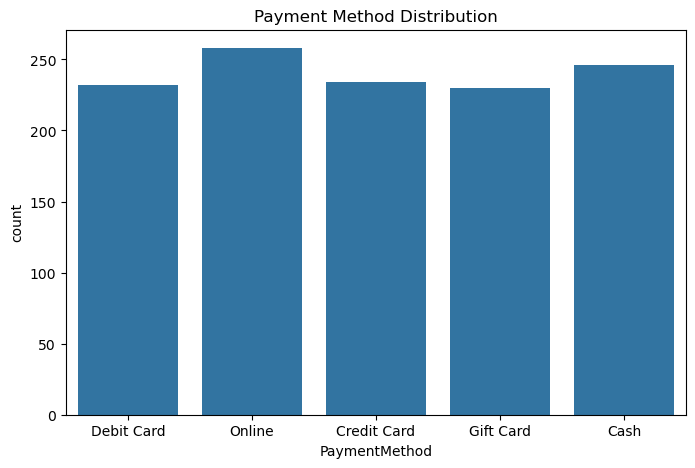

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='PaymentMethod', data=df)
plt.title("Payment Method Distribution")
plt.show()

In [12]:
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

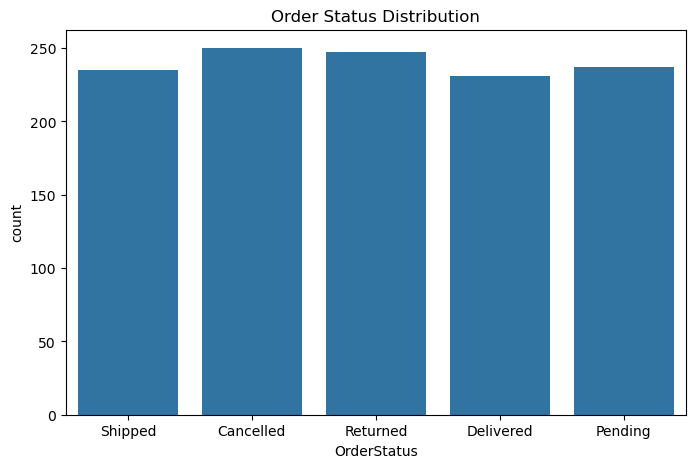

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(x='OrderStatus', data=df)
plt.title("Order Status Distribution")
plt.show()


In [14]:
df['TotalPrice'].sum()

np.float64(1264761.96)

In [15]:
df['TotalPrice'].mean()

np.float64(1053.9683)

In [16]:
df['TotalPrice'].max()

3456.4

In [17]:
df['ReferralSource'].value_counts()

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

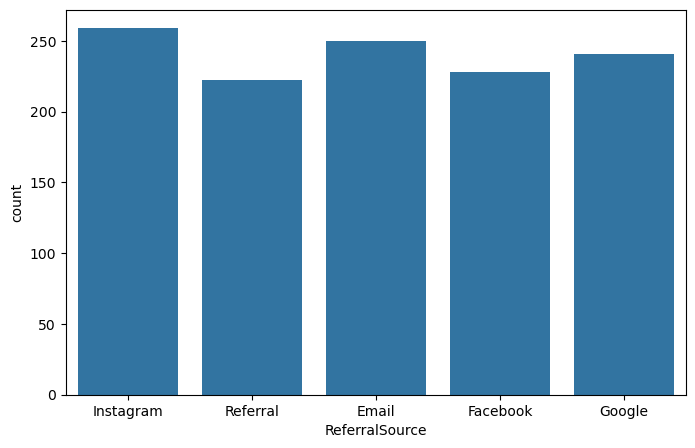

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='ReferralSource', data=df)
plt.show()

In [20]:
df['Date'] = pd.to_datetime(df['Date'])

In [21]:
df['Month'] = df['Date'].dt.month_name()

In [22]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()
monthly_sales

Month
April        109186.05
August        86343.21
December      82540.50
February     112344.78
January      124313.23
July          85784.64
June         170616.13
March        123840.93
May          135142.59
November      75493.43
October       89834.82
September     69321.65
Name: TotalPrice, dtype: float64

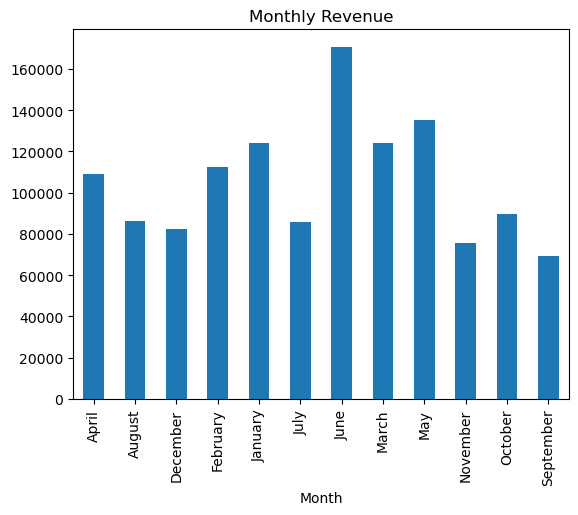

In [23]:
monthly_sales.plot(kind='bar')
plt.title("Monthly Revenue")
plt.show()

In [24]:
product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
product_revenue

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

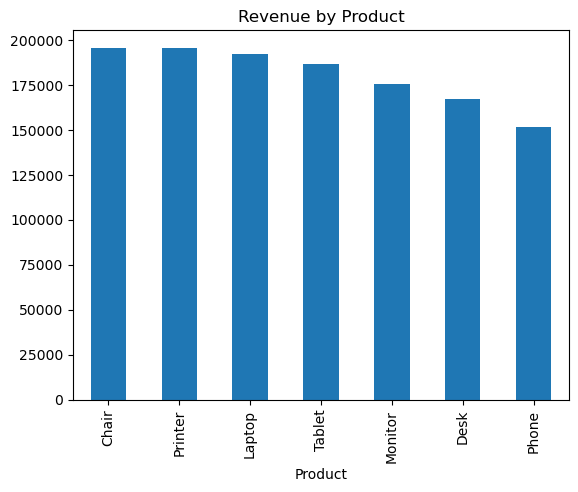

In [25]:
product_revenue.plot(kind='bar')
plt.title("Revenue by Product")
plt.show()

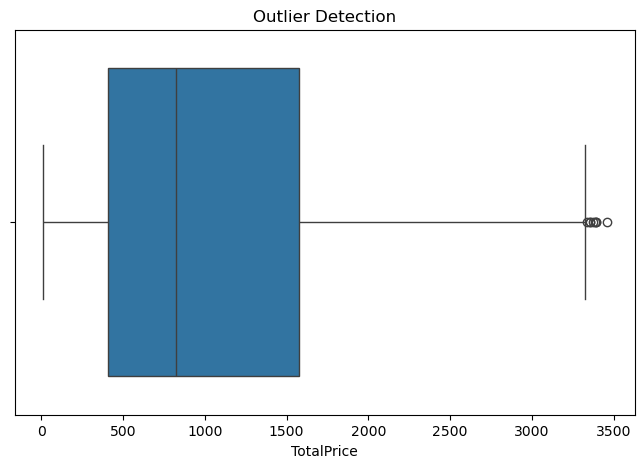

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['TotalPrice'])
plt.title("Outlier Detection")
plt.show()

In [28]:
numeric_df = df[['Quantity','UnitPrice','ItemsInCart','TotalPrice']]
numeric_df.corr()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
Quantity,1.000000,0.014553,0.650061,0.615251
UnitPrice,0.014553,1.000000,0.000602,0.717081
ItemsInCart,0.650061,0.000602,1.000000,0.392540
TotalPrice,0.615251,0.717081,0.392540,1.000000


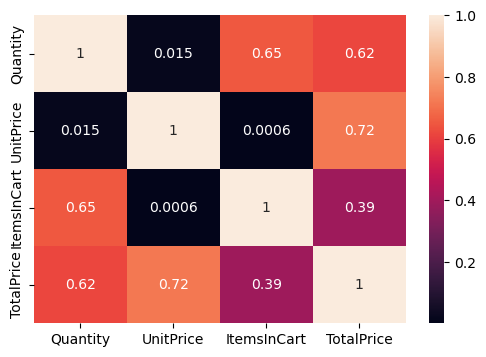

In [29]:
plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()